In [1]:
import matplotlib.pyplot as plt
import numpy as np
import random
from astroML.datasets import fetch_dr7_quasar
from __future__ import print_function
from scipy import stats, interpolate
from astropy.visualization import hist
from astroML.density_estimation import EmpiricalDistribution
import astropy

First method:

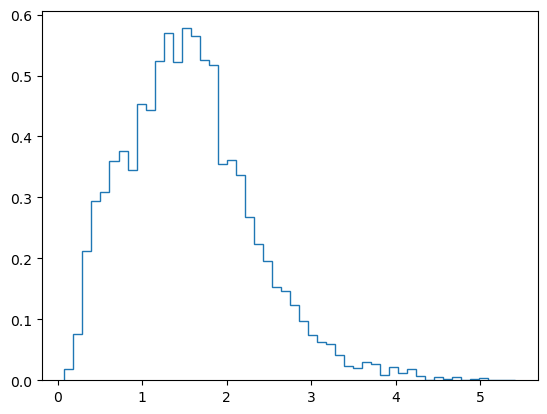

In [2]:
data = fetch_dr7_quasar()
Nbins = 50
# select the first 10000 points
data = data[:10000]

z = data['redshift']

gg = plt.hist(z, bins=Nbins, histtype='step', density=True)

high1 = []
valuesx = []
high1 = gg[0]
valuesx = gg[1]

xmin = min(valuesx)
xmax = max(valuesx)

breadth = (xmax-xmin)/Nbins # breadth of each bin

plt.show()

When I make print(gg) the first array shows the high of the bin and the second one the value of the x measured at the extreme left of the corresponding bin.

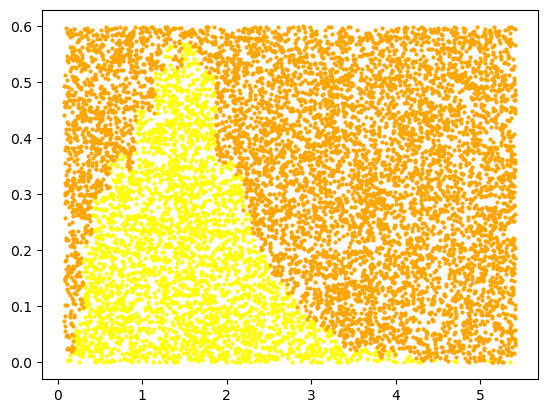

(array([0.01875012, 0.07593799, 0.21187633, 0.29343926, 0.30937702,
        0.36000215, 0.37593996, 0.34500226, 0.45375297, 0.44343991,
        0.52312842, 0.57000373, 0.52219092, 0.57750313, 0.56437869,
        0.52594094, 0.51656588, 0.35531482, 0.36093946, 0.33656433,
        0.26812705, 0.22406372, 0.195939  , 0.15375083, 0.1471883 ,
        0.12281344, 0.09750053, 0.07406307, 0.06281284, 0.05906282,
        0.04218782, 0.02343763, 0.02062511, 0.03000023, 0.02625014,
        0.00843756, 0.02156267, 0.01125006, 0.0187501 , 0.00750004,
        0.00093751, 0.00468753, 0.00187502, 0.00468753, 0.00093751,
        0.00187501, 0.00375002, 0.        , 0.        , 0.00093751]),
 array([0.0802    , 0.186866  , 0.29353198, 0.40019798, 0.50686401,
        0.61352998, 0.72019601, 0.82686198, 0.93352795, 1.04019392,
        1.14686   , 1.25352597, 1.36019194, 1.46685791, 1.573524  ,
        1.68018997, 1.78685594, 1.8935219 , 2.00018787, 2.10685396,
        2.21352005, 2.3201859 , 2.42685199, 2.

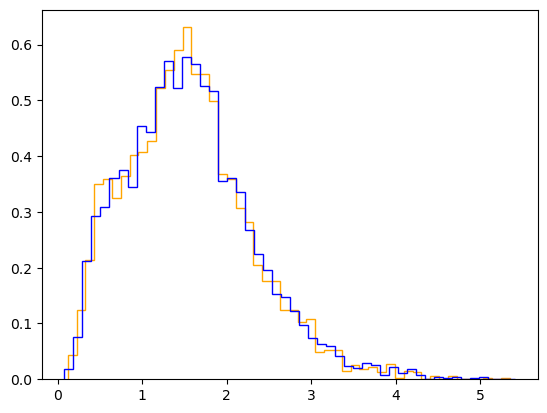

In [3]:
N = 10000
x = np.random.uniform(xmin, xmax, N)
y = np.random.uniform(0, 0.6, N)

high = []
ValuesX = [] # array in which I write N values from the high

# I want a random uniform for a total x number per bin = N*(high of the corresponding bin)

i = 0
while i<len(high1):
    k = 0
    while k<(N/Nbins):
        high.append(high1[i])
        k = k+1
    i = i+1

# ho 50 bins, per ogni bin devo calcolare N*(high of the corresponding bin) numeri

arr = []
voidArr = []
t = 0
while t<len(high1):
    arr = np.linspace(xmin+t*breadth, xmin+t*breadth+breadth, round(N*high1[t])) #/np.sum(high1)
    r = 0
    while r<len(arr):
        variable = arr[r]
        ValuesX.append(variable)
        variable = 0
        r = r+1
    arr = voidArr.copy() # perchè voglio svuotare arr
    t = t+1

# I have to compute the corresponding high for each value of x
valuesX = x.copy()
valuesX.sort()

plt.scatter(valuesX[y<high], y[y<high], c='yellow', s=4)
plt.scatter(valuesX[y>high], y[y>high], c='orange', s=4)

plt.show()
goodpoints = valuesX[y<high]

plt.hist(goodpoints, bins=Nbins, density=True, histtype='step', color='orange')
plt.hist(z, bins=Nbins, histtype='step', density=True, color='blue')

Second method:

(array([0.01875012, 0.07593799, 0.21187633, 0.29343926, 0.30937702,
        0.36000215, 0.37593996, 0.34500226, 0.45375297, 0.44343991,
        0.52312842, 0.57000373, 0.52219092, 0.57750313, 0.56437869,
        0.52594094, 0.51656588, 0.35531482, 0.36093946, 0.33656433,
        0.26812705, 0.22406372, 0.195939  , 0.15375083, 0.1471883 ,
        0.12281344, 0.09750053, 0.07406307, 0.06281284, 0.05906282,
        0.04218782, 0.02343763, 0.02062511, 0.03000023, 0.02625014,
        0.00843756, 0.02156267, 0.01125006, 0.0187501 , 0.00750004,
        0.00093751, 0.00468753, 0.00187502, 0.00468753, 0.00093751,
        0.00187501, 0.00375002, 0.        , 0.        , 0.00093751]),
 array([0.0802    , 0.186866  , 0.29353198, 0.40019798, 0.50686401,
        0.61352998, 0.72019601, 0.82686198, 0.93352795, 1.04019392,
        1.14686   , 1.25352597, 1.36019194, 1.46685791, 1.573524  ,
        1.68018997, 1.78685594, 1.8935219 , 2.00018787, 2.10685396,
        2.21352005, 2.3201859 , 2.42685199, 2.

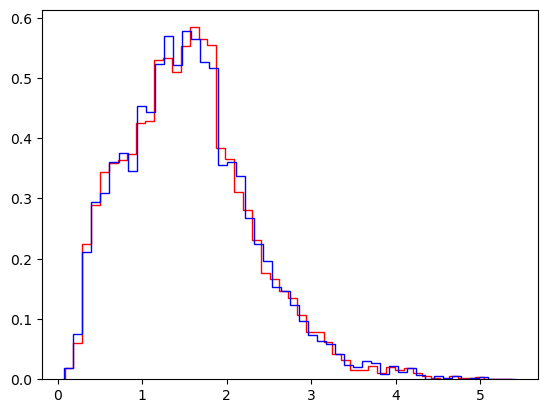

In [4]:
x_cloned = EmpiricalDistribution(ValuesX).rvs(N)
plt.hist(x_cloned, bins=Nbins, histtype='step', density=True, color='red')
plt.hist(z, bins=Nbins, histtype='step', density=True, color='blue')

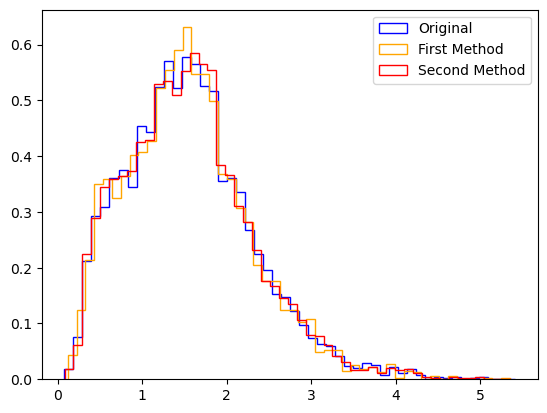

In [5]:
plt.hist(z, bins=Nbins, histtype='step', density=True, color='blue', label="Original")
plt.hist(goodpoints, bins=Nbins, density=True, histtype='step', color='orange', label="First Method")
plt.hist(x_cloned, bins=Nbins, histtype='step', density=True, color='red', label="Second Method")

plt.legend()
plt.show()

I have in order (nowadays):
1. name.
2. value of the Hubble constant.
3. value of $\Omega$ matter.
4. temperature of the CMB.
5. Neff is the number of neutrino's species.
6. m_nu that I don't know what is (but it is an energy :)).
7. value of $\Omega$ baryons.

In [6]:
astropy.cosmology.Planck15

FlatLambdaCDM(name="Planck15", H0=67.74 km / (Mpc s), Om0=0.3075, Tcmb0=2.7255 K, Neff=3.046, m_nu=[0.   0.   0.06] eV, Ob0=0.0486)

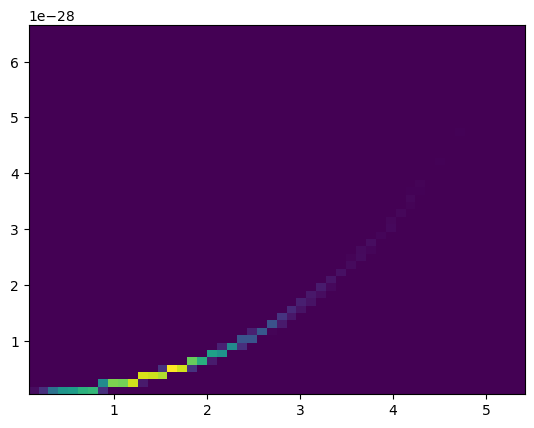

In [13]:
from astropy.cosmology import WMAP7
omegam = [] # array containing the values of omega matter at different redshifts

cosmo = astropy.cosmology.Planck18
omegam = cosmo.Om(z)

density = omegam*WMAP7.critical_density(z).value

plt.hist2d(z, density, bins=Nbins, density=True)
plt.show()